In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from scipy.spatial.distance import pdist

In [ ]:
configs = np.load("LJ13_configs.npy")

In [ ]:
X = configs.reshape(configs.shape[0],39)
X = torch.tensor(X, dtype=torch.float32)

X_np = X.cpu().numpy()

#sigma_max = pdist(X_np).max()
sigma_max = 10;
sigma_min = 0.01
print(sigma_max,sigma_min)

10 0.01


Chose sigma_max as 10, because the maximum pairwise distance was too large (~82)

In [4]:
def get_sigma(t):

    return sigma_min * (sigma_max/sigma_min)**t

In [5]:
def train_model(
  optimizer_name="Adam",
  lr = 5e-4,
  batch_size = 100,
  width = 128,
  depth = 3,
  num_epochs = 10000      
):
    dataset = TensorDataset(X)

    loader = DataLoader(dataset,batch_size=batch_size,shuffle=True)

    layers = []

    layers.append(nn.Linear(40,width))
    layers.append(nn.ReLU())

    for _ in range(depth-1):
        layers.append(nn.Linear(width,width))
        layers.append(nn.ReLU())


    layers.append(nn.Linear(width,39))

    model = nn.Sequential(*layers)

    if optimizer_name == "Adam":
        
        optimizer=optim.Adam(
            model.parameters(),
            lr=lr
        )
    else:

        optimizer = optim.SGD(
            model.parameters(),
            lr=lr
        )
    

    loss_history = []

    for epoch in range(num_epochs):
        
        epoch_loss = 0.0

        for (x_batch,) in loader:
            
            batch_size_current = x_batch.shape[0]
            
            t = torch.rand(batch_size_current,1)

            sigma = get_sigma(t)

            noise = torch.randn_like(x_batch)
            
            x_noisy = x_batch + sigma * noise
            
            target = -noise / sigma

            model_input = torch.cat([x_noisy, sigma], dim=1)

            score_pred = model(model_input)

            loss_per_sample = ((score_pred - target) ** 2).sum(dim=1)

            weights = sigma.squeeze() ** 2

            loss = (weights * loss_per_sample).mean()

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()
            
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        loss_history.append(avg_loss)

        if epoch % 100 == 0:
            print(f"Epoch {epoch:4d} | Loss = {avg_loss:.6f}")

    return model, loss_history

In [6]:
model, loss_history = train_model()

Epoch    0 | Loss = 40.389320
Epoch  100 | Loss = 22.653267
Epoch  200 | Loss = 20.020300
Epoch  300 | Loss = 19.522054
Epoch  400 | Loss = 18.856206
Epoch  500 | Loss = 18.608804
Epoch  600 | Loss = 20.788454
Epoch  700 | Loss = 18.319998
Epoch  800 | Loss = 18.210346
Epoch  900 | Loss = 18.171433
Epoch 1000 | Loss = 17.830889
Epoch 1100 | Loss = 18.486773
Epoch 1200 | Loss = 17.763865
Epoch 1300 | Loss = 17.649465
Epoch 1400 | Loss = 17.464586
Epoch 1500 | Loss = 17.410251
Epoch 1600 | Loss = 17.366561
Epoch 1700 | Loss = 17.251350
Epoch 1800 | Loss = 17.309388
Epoch 1900 | Loss = 17.243992
Epoch 2000 | Loss = 19.921189
Epoch 2100 | Loss = 17.148820
Epoch 2200 | Loss = 17.055822
Epoch 2300 | Loss = 17.120280
Epoch 2400 | Loss = 17.943531
Epoch 2500 | Loss = 17.058418
Epoch 2600 | Loss = 17.031524
Epoch 2700 | Loss = 16.908966
Epoch 2800 | Loss = 16.982201
Epoch 2900 | Loss = 16.971540
Epoch 3000 | Loss = 16.998743
Epoch 3100 | Loss = 18.169091
Epoch 3200 | Loss = 17.610545
Epoch 3300

[19.92118878173828, 18.930362003326415, 18.54392008972168, 18.22595082473755, 18.184168704986572, 18.155232246398924, 17.865441024780274, 17.728077789306642, 17.797143039703368, 17.684534439086914, 17.705633060455323, 22.744018615722656, 18.573964694976805, 18.039221893310547, 17.86454458618164, 18.60560467147827, 17.765500949859618, 17.672995475769042, 17.823638439178467, 18.16718190765381, 17.61997636413574, 17.47699917984009, 17.25473504638672, 17.362054332733155, 17.308764038085936, 18.135673141479494, 17.503182033538817, 17.772580181121825, 17.575821620941163, 17.40869194793701, 17.17619934463501, 17.234393306732176, 17.21520351409912, 17.235480876922608, 17.170695617675783, 17.163915531158448, 17.221501708984373, 17.204646015167235, 17.248083827972412, 17.20557775115967, 17.13068801879883, 17.172608043670653, 17.231793529510497, 17.29084349822998, 17.120776847839355, 17.174678733825683, 17.18879712295532, 17.21809242630005, 17.661037300109864, 17.36086466217041, 17.21247908020019

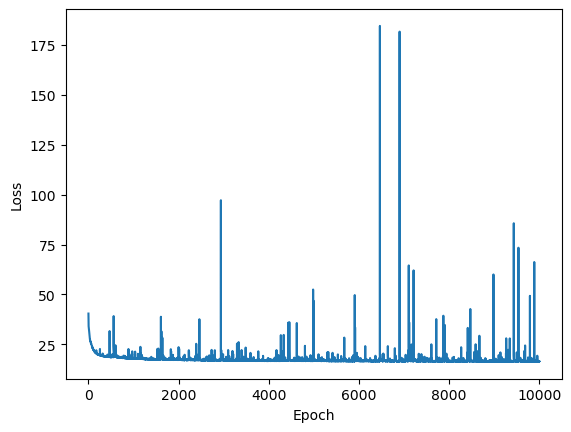

In [9]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")

print(loss_history[2000:])

A lot of fluctuations are observed in the Loss vs epoch curve, probably due to the training samples being so different from each other (since no invariances are added)

In [10]:
def g(t):

    sigma = get_sigma(t)

    return (sigma * np.sqrt(2*np.log(sigma_max/sigma_min)))

In [217]:
def predictor_corrector_sampler(
    model,
    n_samples=1000,
    n_steps=1000,
    n_corrector=1,
    snr=0.16
):

    model.eval()

    x = torch.randn(n_samples, 39) * sigma_max

    dt = 1.0 / n_steps
    sqrt_dt = np.sqrt(dt)


    with torch.no_grad():

        for i in range(n_steps):

            t = 1 - i / n_steps

            t_tensor = torch.full((n_samples,1), t)

            sigma = get_sigma(t_tensor)

            g_val = g(t_tensor)


            model_input = torch.cat([x, sigma], dim=1)

            score = model(model_input)


            noise = torch.randn_like(x)

            x = (x + (g_val**2) * score * dt + g_val * sqrt_dt * noise)


            for _ in range(n_corrector):

                sigma = get_sigma(t_tensor)

                model_input = torch.cat([x, sigma], dim=1)

                score = model(model_input)

                noise = torch.randn_like(x)

                score_norm = torch.norm(score.reshape(n_samples, -1), dim=1).mean()


                noise_norm = torch.norm(noise.reshape(n_samples,-1), dim=1).mean()

                eps = (2 * (snr * noise_norm / score_norm)**2)
                eps = torch.clamp(eps, max=0.05)

                x = (x + eps * score + torch.sqrt(2*eps) * noise)


    return x

I put a cap on the eps because the x was exploding otherwise, and no meaningful sampling could be done. This was probably due to the corrector Langevin steps getting too large and hence the score 

In [218]:
samples = predictor_corrector_sampler(model, n_samples=5000, n_steps=1000, n_corrector=1, snr=0.16)

In [219]:
samples = samples.cpu().numpy()
configs_generated = samples.reshape(-1,13,3)
n_atoms = configs_generated.shape[1]
epsilon = 1
sigma = 1

In [220]:
def lj_energy(positions):

    N = n_atoms

    energy = 0.0

    for i in range(N):
        for j in range(i+1, N):

            rij = positions[i] - positions[j]

            r = np.linalg.norm(rij)

            energy += 4 * epsilon * ((sigma/r)**12 - (sigma/r)**6)

    return energy

In [221]:
generated_energies = np.array([lj_energy(config) for config in configs_generated])

In [222]:
configs_generated[0]

array([[-5.3033814 ,  5.2510962 , -0.59780633],
       [-4.0512686 ,  3.8712497 , -2.5451949 ],
       [-5.4657254 ,  4.006605  , -1.2275444 ],
       [-4.96592   ,  5.0203657 ,  0.65663165],
       [-2.5313532 ,  4.9022403 , -1.2071828 ],
       [-3.2761366 ,  5.605858  ,  0.60775113],
       [-0.81578594,  3.3754196 , -0.9621567 ],
       [-2.8554978 ,  2.9588642 , -2.2419686 ],
       [-1.2325544 ,  3.4317589 , -2.2973206 ],
       [-3.5223641 ,  3.5922196 , -0.39002612],
       [-2.0967236 ,  4.6616364 ,  0.82513225],
       [-0.6945924 ,  4.5868583 , -0.26789305],
       [-2.9946773 ,  4.3384323 , -0.80452585]], dtype=float32)

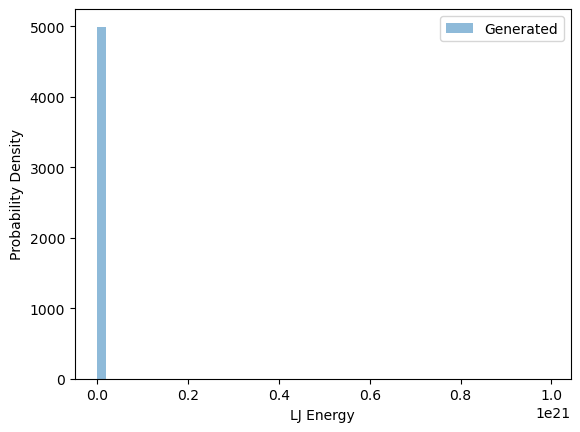

In [223]:
plt.hist(generated_energies, bins=50, alpha=0.5, label="Generated")

plt.xlabel("LJ Energy")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

This is the first histogram considering all the generated samples, later only considered a specific window of energies (<0)


In [ ]:
training_energies = np.array([lj_energy(config) for config in configs_generated])

In [255]:
generated_plot = generated_energies[
    generated_energies < 0
]

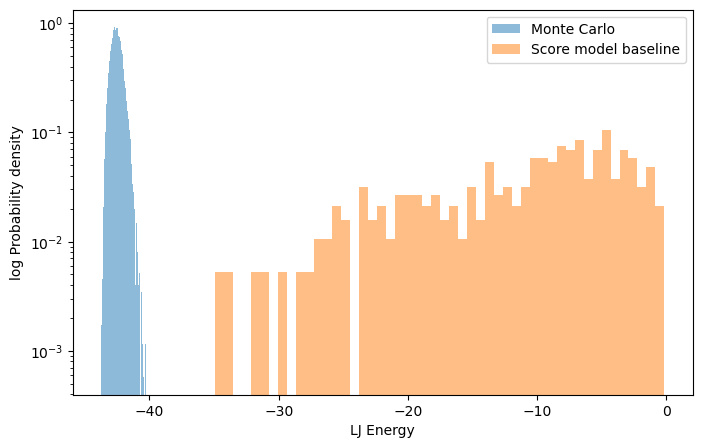

In [256]:
plt.figure(figsize=(8,5))

plt.hist(
    training_energies,
    bins=50,
    density=True,
    alpha=0.5,
    label="Monte Carlo"
)

plt.hist(
    generated_plot,
    bins=50,
    density=True,
    alpha=0.5,
    label="Score model baseline"
)

plt.yscale("log")

plt.xlabel("LJ Energy")
plt.ylabel("log Probability density")
plt.legend()
plt.show()

A comparison between the MC samples (training data set) and the generated samples energies. A tiny fraction of the samples are close to the MC samples

In [245]:
mc_distances = []

for config in configs:
    d = pdist(config)   # 78 distances
    mc_distances.extend(d)

mc_distances = np.array(mc_distances)

print(mc_distances.shape)

(1949532,)


In [246]:
generated_distances = []

for config in configs_generated:
    d = pdist(config)
    generated_distances.extend(d)

generated_distances = np.array(generated_distances)

print(generated_distances.shape)

(390000,)


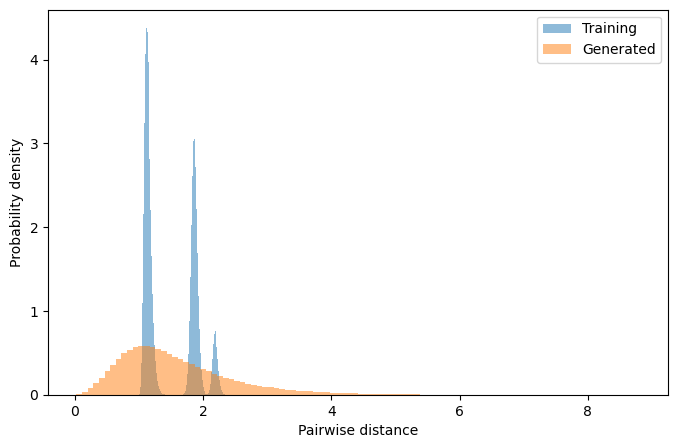

In [254]:
plt.figure(figsize=(8,5))

plt.hist(
    mc_distances,
    bins=100,
    density=True,
    alpha=0.5,
    label="Training"
)

plt.hist(
    generated_distances,
    bins=100,
    density=True,
    alpha=0.5,
    label="Generated"
)

plt.xlabel("Pairwise distance")
plt.ylabel("Probability density")
plt.legend()
plt.show()

Max pairwise distance of the generated samples do not completely agree with the training data set, but there are generated samples present in that range.

Large pairwise distance indicate atoms are far away, and approximately 0 pairwise distance indicate atoms have collapsed into one another

In [248]:
valid = generated_energies < 0

valid_configs = configs_generated[valid]

In [ ]:
print(len(valid_configs), "valid configurations")

271 valid configurations


only 271/5000=5.42% are configurations which have LJ potential less than 0 